<a href="https://colab.research.google.com/github/mazen259/data-cleaning-machine-learning-/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


## read data

In [ ]:
df = pd.read_csv(r"student_performance_prediction.csv")

## basic Information About Dataset

In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  str    
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  str    
 5   Parent Education Level                       38000 non-null  str    
 6   Passed                                       38000 non-null  str    
dtypes: float64(3), str(4)
memory usage: 2.1 MB


,Study Hours per Week,Attendance Rate,Previous Grades
count,38005.000000,38008.000000,38006.000000
mean,9.962744,75.276323,65.440107
std,5.031154,20.393418,16.503119
min,-12.300000,-14.300000,8.300000
25%,6.600000,61.600000,55.100000
50%,10.000000,75.300000,65.200000
75%,13.400000,88.800000,75.200000
max,32.400000,150.200000,200.000000


# 1 Data Cleaning



### Check Missing Values

In [ ]:
df.isnull().sum()

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

### Handle Missing Values


#### Check Skewness

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(col, df[col].skew())

Study Hours per Week -0.011689034148937962
Attendance Rate 0.08928153405054809
Previous Grades 1.3737279541405916


In [ ]:
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

#### Remove Duplicate

In [ ]:
df.drop_duplicates(inplace=True)

#### Feature Engineering

##### Study Efficiency Feature

Why this step was performed:
This feature was created to combine study hours and attendance rate into a single metric that represents how efficiently a student studies.

Insight / Conclusion:
Students who study more hours and attend classes regularly may have higher study efficiency, which could positively influence their academic performance.

In [ ]:
df["Study Efficiency"] = df["Study Hours per Week"] * df["Attendance Rate"]
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Study Efficiency
0,S00001,12.5,NaN,75.0,Yes,Master,Yes,NaN
1,S00002,9.3,95.3,60.6,No,High School,No,886.29
2,S00003,13.2,NaN,64.0,No,Associate,No,NaN
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No,1351.68
4,S00005,8.8,89.3,72.7,No,Master,No,785.84


#### Detect Outliers

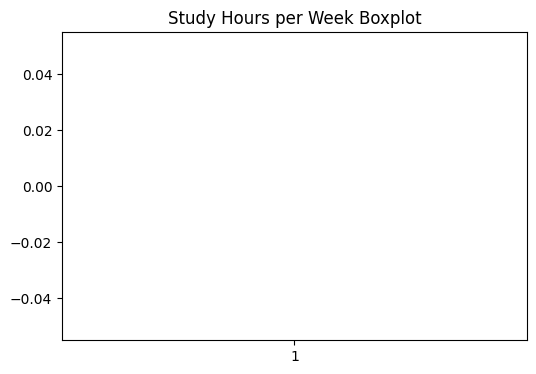

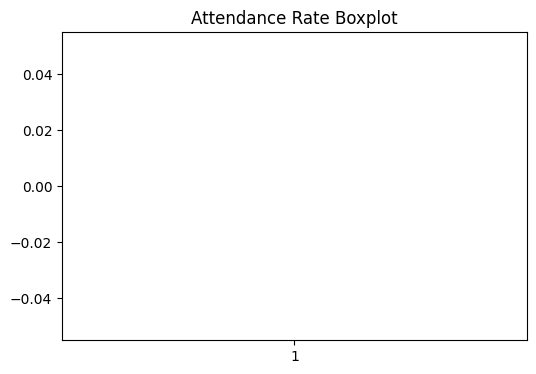

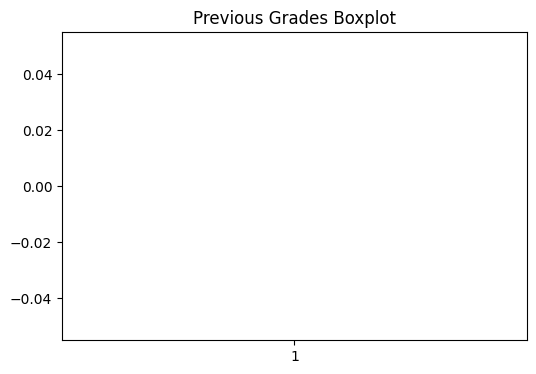

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Study Hours per Week"])
plt.title("Study Hours per Week Boxplot")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df["Attendance Rate"])
plt.title("Attendance Rate Boxplot")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df["Previous Grades"])
plt.title("Previous Grades Boxplot")
plt.show()

 # 2 EDA (Visualization)


### Explanation

Why this step was performed:
This visualization was created to analyze the relationship between study hours and whether students passed or failed.

Insight / Conclusion:
The chart shows that students who passed tend to study more hours per week compared to those who failed. This suggests that study time may have a positive impact on student performance.

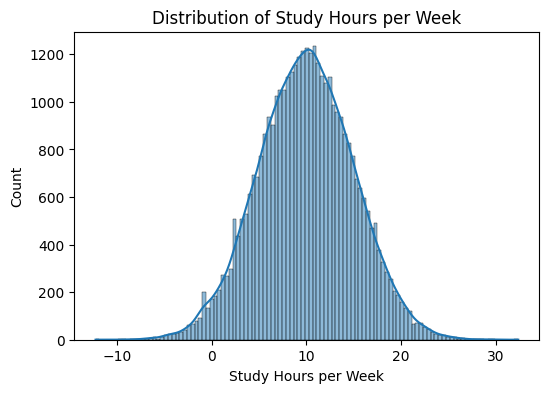

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Study Hours per Week"], kde=True)
plt.title("Distribution of Study Hours per Week")
plt.show()

### Explanation

Why this step was performed:
This histogram was created to understand the distribution of students' attendance rates.

Insight / Conclusion:
The distribution shows how attendance is spread among students and helps identify whether most students have high or low attendance rates.

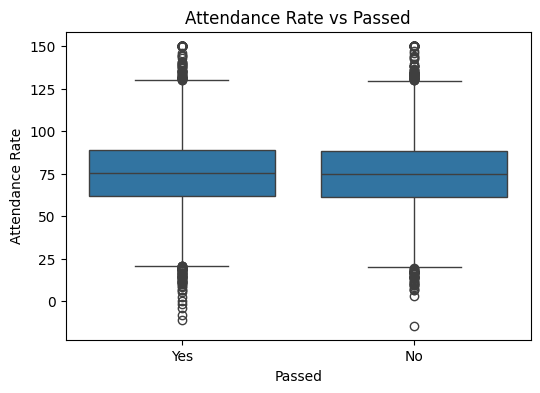

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Passed", y="Attendance Rate", data=df)
plt.title("Attendance Rate vs Passed")
plt.show()

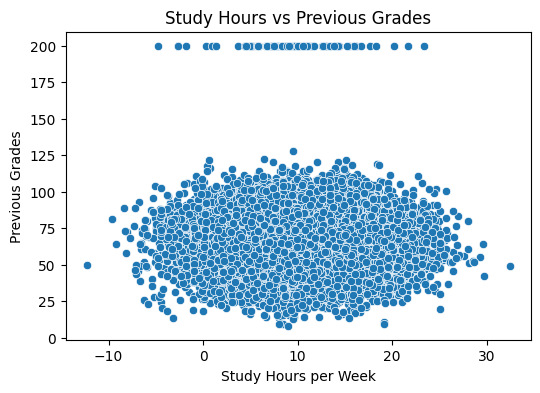

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Study Hours per Week", y="Previous Grades", data=df)
plt.title("Study Hours vs Previous Grades")
plt.show()

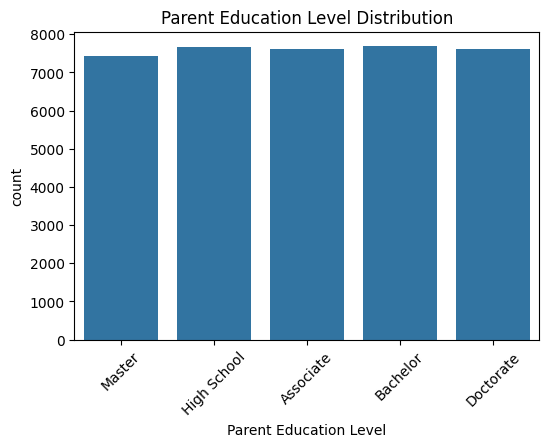

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Parent Education Level", data=df)
plt.title("Parent Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

# Encode &  Remove Unnecessary Column & Scaling

In [ ]:
df["Participation in Extracurricular Activities"] = df["Participation in Extracurricular Activities"].replace({
    "Yes": 1, "No": 0, "yes": 1, "no": 0
})

df["Passed"] = df["Passed"].replace({
    "Yes": 1, "No": 0, "yes": 1, "no": 0
})
df["Parent Education Level"] = df["Parent Education Level"].replace({
    "High School": 0,
    "Bachelor": 1,
    "Master": 2,
    "Associate": 3
})

df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Study Efficiency
0,S00001,12.5,NaN,75.0,1,2,1,NaN
1,S00002,9.3,95.3,60.6,0,0,0,886.29
2,S00003,13.2,NaN,64.0,0,3,0,NaN
3,S00004,17.6,76.8,62.4,1,1,0,1351.68
4,S00005,8.8,89.3,72.7,0,2,0,785.84


#### Remove Unnecessary Column

In [ ]:
df.columns = df.columns.str.strip()
df.drop(columns=["Student ID"], inplace=True)
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Study Efficiency
0,12.5,NaN,75.0,1,2,1,NaN
1,9.3,95.3,60.6,0,0,0,886.29
2,13.2,NaN,64.0,0,3,0,NaN
3,17.6,76.8,62.4,1,1,0,1351.68
4,8.8,89.3,72.7,0,2,0,785.84


### Feature Scaling

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = (df[numeric_cols] - df[numeric_cols].median()) / df[numeric_cols].std()


# 3 Show Final Data

In [ ]:
df.head()

,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Study Efficiency
0,0.496904,NaN,0.593827,1,2,1,NaN
1,-0.139133,0.980709,-0.278735,0,0,0,0.401978
2,0.636037,NaN,-0.072714,0,3,0,NaN
3,1.510588,0.073553,-0.169665,1,1,0,1.456582
4,-0.238514,0.686496,0.454460,0,2,0,0.174351
